In [1]:
# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [2]:
#Verifying GPU Availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:

transform = transforms.Compose([
    transforms.ToTensor(),
])

#Fashion MNIST Training Data
Fashion_mnist_train_validation = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)
Fashion_mnist_train , Fashion_mnist_validate  = random_split(
    Fashion_mnist_train_validation, [50000, 10000], generator=torch.Generator().manual_seed(1)
)

#Fashion MNIST Testing Data
Fashion_mnist_test = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

#DataLoader divides the dataset into mini-batches.
#shuffle randomizes the chosen sets.
Fashion_mnist_train_loader = DataLoader(
    Fashion_mnist_train,
    batch_size=512,
    num_workers=2,   
    pin_memory=True,
    shuffle=True
)
Fashion_mnist_validate_loader = DataLoader(
    Fashion_mnist_validate,
    batch_size=512,
    num_workers=2,   
    pin_memory=True,
    shuffle=False
)
Fashion_mnist_test_loader = DataLoader(
    Fashion_mnist_test,
    batch_size=512,
    num_workers=2,   
    pin_memory=True,
    shuffle=False
)

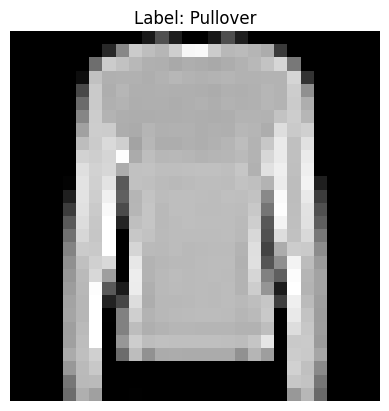

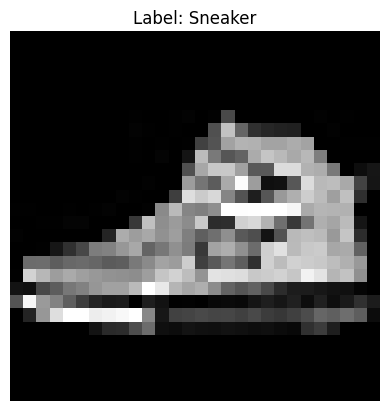

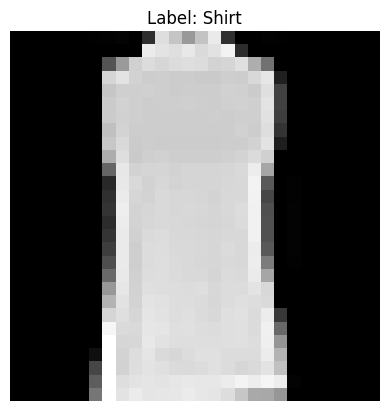

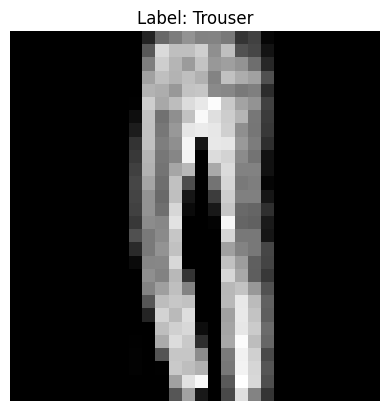

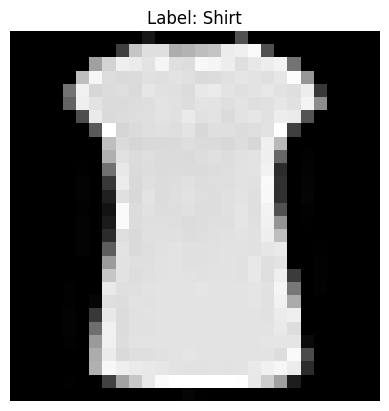

In [4]:
#Defining the Classes
class_names =["T-shirt/top","Trouser", "Pullover","Dress","Coat", "Sandal","Shirt","Sneaker","Bag", "Ankle boot"]

for i in range(5):
  image,label=Fashion_mnist_train[i]
  plt.figure()
  # Squeeze or rearrange dimensions because PyTorch uses [Channels, Height, Width]
  plt.imshow(image.squeeze(), cmap='gray')
  plt.title(f"Label: {class_names[label]}")
  plt.axis('off')
  plt.show()

In [5]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        
        self.flatten = nn.Flatten()
        
        #784->256->128->latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        
        #784<-256<-128-<latent_dim
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )
        

    def forward(self, x):
        x=self.flatten(x)
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed


Training Autoencoder with latent_dim = 8
Epoch [1/100] | Train Loss: 0.120067 | Val Loss: 0.089854
Epoch [2/100] | Train Loss: 0.074593 | Val Loss: 0.054410
Epoch [3/100] | Train Loss: 0.047038 | Val Loss: 0.041502
Epoch [4/100] | Train Loss: 0.039294 | Val Loss: 0.036456
Epoch [5/100] | Train Loss: 0.034873 | Val Loss: 0.032733
Epoch [6/100] | Train Loss: 0.031882 | Val Loss: 0.030449
Epoch [7/100] | Train Loss: 0.029805 | Val Loss: 0.028622
Epoch [8/100] | Train Loss: 0.028143 | Val Loss: 0.027431
Epoch [9/100] | Train Loss: 0.026448 | Val Loss: 0.025167
Epoch [10/100] | Train Loss: 0.024939 | Val Loss: 0.023909
Epoch [11/100] | Train Loss: 0.023799 | Val Loss: 0.022962
Epoch [12/100] | Train Loss: 0.022996 | Val Loss: 0.022339
Epoch [13/100] | Train Loss: 0.022358 | Val Loss: 0.021684
Epoch [14/100] | Train Loss: 0.021708 | Val Loss: 0.021118
Epoch [15/100] | Train Loss: 0.021221 | Val Loss: 0.020686
Epoch [16/100] | Train Loss: 0.020777 | Val Loss: 0.020268
Epoch [17/100] | Train 

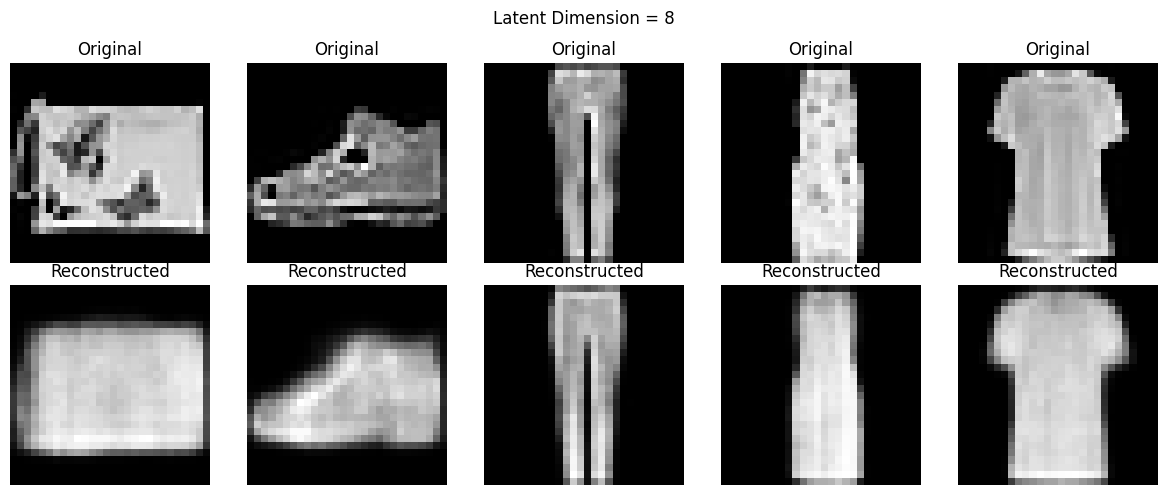


Training Autoencoder with latent_dim = 16
Epoch [1/100] | Train Loss: 0.120782 | Val Loss: 0.082731
Epoch [2/100] | Train Loss: 0.068320 | Val Loss: 0.053515
Epoch [3/100] | Train Loss: 0.047552 | Val Loss: 0.042227
Epoch [4/100] | Train Loss: 0.040254 | Val Loss: 0.037416
Epoch [5/100] | Train Loss: 0.036171 | Val Loss: 0.034498
Epoch [6/100] | Train Loss: 0.033109 | Val Loss: 0.031161
Epoch [7/100] | Train Loss: 0.030160 | Val Loss: 0.028623
Epoch [8/100] | Train Loss: 0.027843 | Val Loss: 0.026774
Epoch [9/100] | Train Loss: 0.025969 | Val Loss: 0.024853
Epoch [10/100] | Train Loss: 0.024980 | Val Loss: 0.023862
Epoch [11/100] | Train Loss: 0.023721 | Val Loss: 0.023028
Epoch [12/100] | Train Loss: 0.022956 | Val Loss: 0.022701
Epoch [13/100] | Train Loss: 0.022511 | Val Loss: 0.022060
Epoch [14/100] | Train Loss: 0.022039 | Val Loss: 0.021493
Epoch [15/100] | Train Loss: 0.021652 | Val Loss: 0.021106
Epoch [16/100] | Train Loss: 0.021246 | Val Loss: 0.020719
Epoch [17/100] | Train

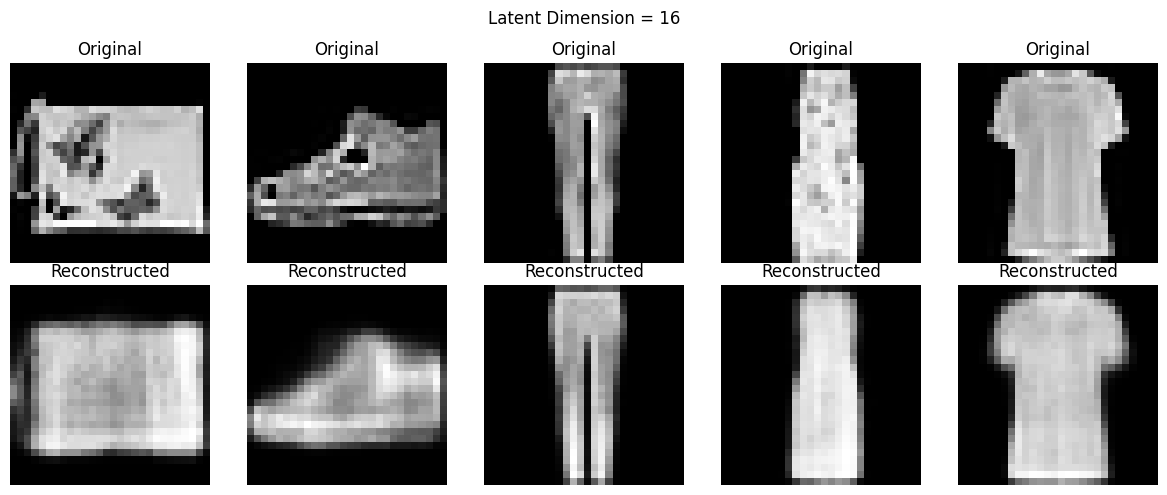


Training Autoencoder with latent_dim = 32
Epoch [1/100] | Train Loss: 0.121504 | Val Loss: 0.088830
Epoch [2/100] | Train Loss: 0.071948 | Val Loss: 0.056513
Epoch [3/100] | Train Loss: 0.050204 | Val Loss: 0.045292
Epoch [4/100] | Train Loss: 0.042676 | Val Loss: 0.039700
Epoch [5/100] | Train Loss: 0.038035 | Val Loss: 0.036538
Epoch [6/100] | Train Loss: 0.034553 | Val Loss: 0.032503
Epoch [7/100] | Train Loss: 0.031061 | Val Loss: 0.029323
Epoch [8/100] | Train Loss: 0.029590 | Val Loss: 0.027368
Epoch [9/100] | Train Loss: 0.026857 | Val Loss: 0.025799
Epoch [10/100] | Train Loss: 0.025482 | Val Loss: 0.024689
Epoch [11/100] | Train Loss: 0.024650 | Val Loss: 0.023924
Epoch [12/100] | Train Loss: 0.023884 | Val Loss: 0.023161
Epoch [13/100] | Train Loss: 0.023244 | Val Loss: 0.022589
Epoch [14/100] | Train Loss: 0.022641 | Val Loss: 0.022066
Epoch [15/100] | Train Loss: 0.022414 | Val Loss: 0.021738
Epoch [16/100] | Train Loss: 0.021851 | Val Loss: 0.021332
Epoch [17/100] | Train

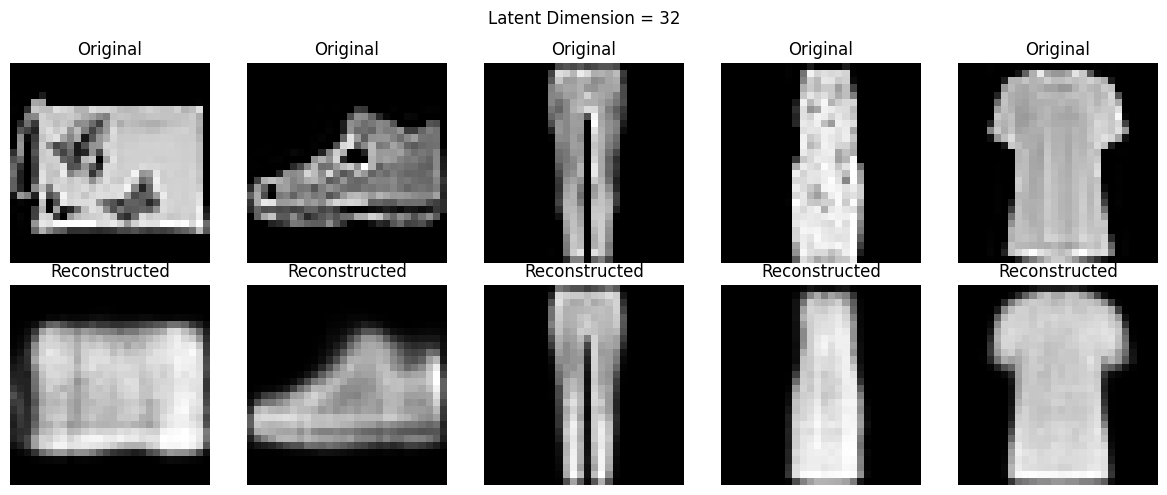


Training Autoencoder with latent_dim = 64
Epoch [1/100] | Train Loss: 0.122425 | Val Loss: 0.091298
Epoch [2/100] | Train Loss: 0.075800 | Val Loss: 0.060581
Epoch [3/100] | Train Loss: 0.052160 | Val Loss: 0.044888
Epoch [4/100] | Train Loss: 0.042257 | Val Loss: 0.039671
Epoch [5/100] | Train Loss: 0.037800 | Val Loss: 0.036233
Epoch [6/100] | Train Loss: 0.034541 | Val Loss: 0.032569
Epoch [7/100] | Train Loss: 0.031244 | Val Loss: 0.029459
Epoch [8/100] | Train Loss: 0.028843 | Val Loss: 0.027027
Epoch [9/100] | Train Loss: 0.026667 | Val Loss: 0.025475
Epoch [10/100] | Train Loss: 0.026283 | Val Loss: 0.025029
Epoch [11/100] | Train Loss: 0.024546 | Val Loss: 0.023690
Epoch [12/100] | Train Loss: 0.023574 | Val Loss: 0.022956
Epoch [13/100] | Train Loss: 0.022907 | Val Loss: 0.022503
Epoch [14/100] | Train Loss: 0.022452 | Val Loss: 0.022144
Epoch [15/100] | Train Loss: 0.022203 | Val Loss: 0.021602
Epoch [16/100] | Train Loss: 0.021599 | Val Loss: 0.021175
Epoch [17/100] | Train

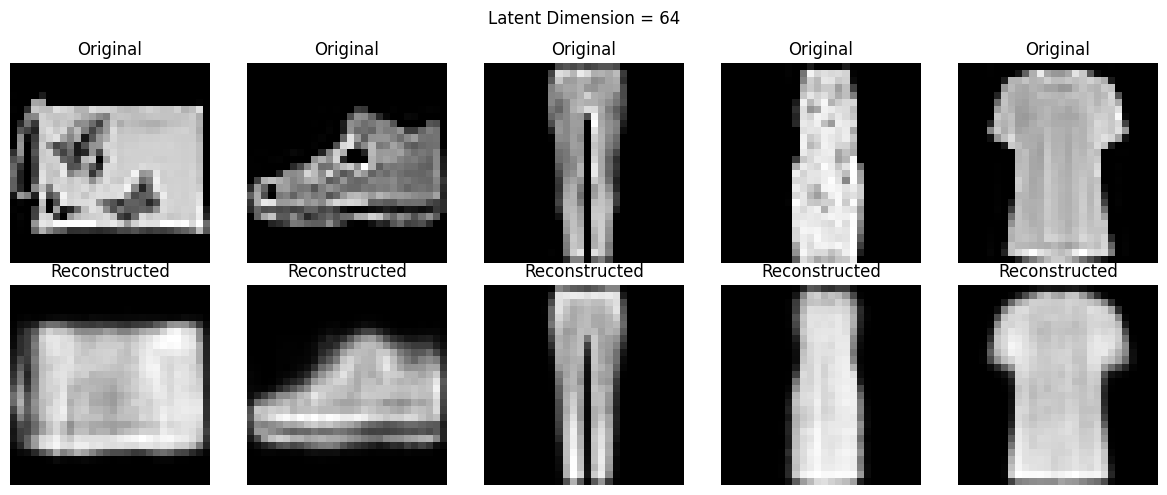


Training Autoencoder with latent_dim = 128
Epoch [1/100] | Train Loss: 0.120771 | Val Loss: 0.088985
Epoch [2/100] | Train Loss: 0.070169 | Val Loss: 0.053062
Epoch [3/100] | Train Loss: 0.047883 | Val Loss: 0.042730
Epoch [4/100] | Train Loss: 0.041072 | Val Loss: 0.039312
Epoch [5/100] | Train Loss: 0.037644 | Val Loss: 0.035583
Epoch [6/100] | Train Loss: 0.034569 | Val Loss: 0.032530
Epoch [7/100] | Train Loss: 0.031882 | Val Loss: 0.030127
Epoch [8/100] | Train Loss: 0.029846 | Val Loss: 0.028251
Epoch [9/100] | Train Loss: 0.028137 | Val Loss: 0.026358
Epoch [10/100] | Train Loss: 0.025841 | Val Loss: 0.024861
Epoch [11/100] | Train Loss: 0.024664 | Val Loss: 0.023834
Epoch [12/100] | Train Loss: 0.023837 | Val Loss: 0.023302
Epoch [13/100] | Train Loss: 0.022944 | Val Loss: 0.022420
Epoch [14/100] | Train Loss: 0.022383 | Val Loss: 0.022517
Epoch [15/100] | Train Loss: 0.021949 | Val Loss: 0.021662
Epoch [16/100] | Train Loss: 0.021397 | Val Loss: 0.020711
Epoch [17/100] | Trai

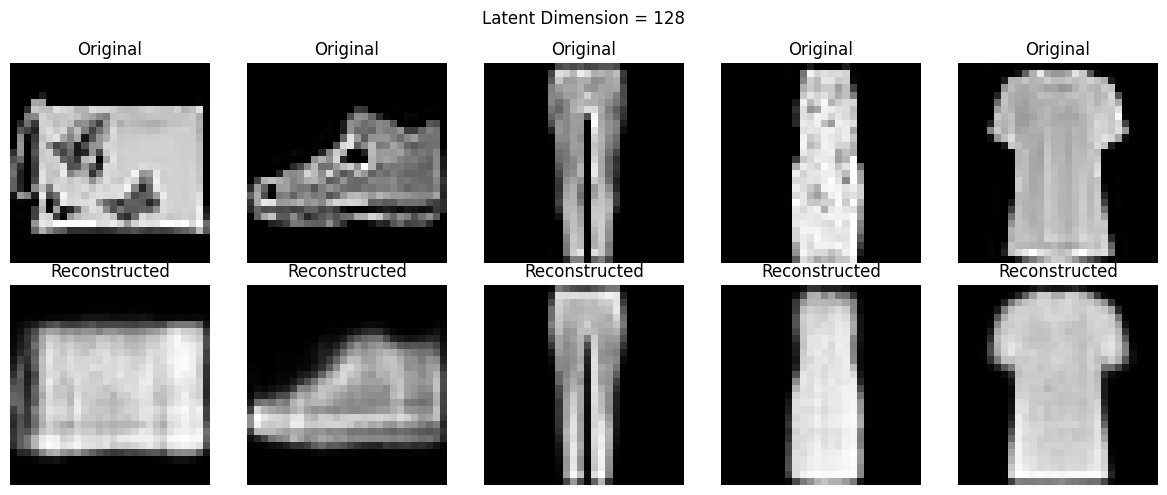


Final Results


,Latent Dimension,Validation Loss
0,8,0.014548
1,16,0.012932
2,32,0.012576
3,64,0.012686
4,128,0.012279


In [ ]:
latent_dims = [8, 16, 32, 64, 128]

results = {}

all_train_images = Fashion_mnist_train.dataset.data[Fashion_mnist_train.indices].float().unsqueeze(1).to(device) / 255.0
all_val_images = Fashion_mnist_validate.dataset.data[Fashion_mnist_validate.indices].float().unsqueeze(1).to(device) / 255.0

epochs = 100
batch_size = 2048

for latent_dim in latent_dims:
    print(f"\nTraining Autoencoder with latent_dim = {latent_dim}")
    model = AutoEncoder(latent_dim=latent_dim).to(device)
    loss = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        num_batches = 0

        for batch_start in range(0, len(all_train_images), batch_size):
            images = all_train_images[batch_start:batch_start + batch_size]
            optimizer.zero_grad()
            reconstructed = model(images)
            target = images.view(images.size(0), -1)
            current_loss = loss(reconstructed, target)
            current_loss.backward()
            optimizer.step()
            running_loss += current_loss.item()
            num_batches += 1

        epoch_train_loss = running_loss / num_batches
        train_losses.append(epoch_train_loss)
        model.eval()

        with torch.no_grad():
            reconstructed = model(all_val_images)
            target = all_val_images.view(all_val_images.size(0), -1)
            epoch_val_loss = loss(reconstructed, target).item()

        val_losses.append(epoch_val_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {epoch_train_loss:.6f} | "
            f"Val Loss: {epoch_val_loss:.6f}"
        )

    results[latent_dim] = epoch_val_loss

    print(f"\nLatent Dimension {latent_dim} Final Val Loss = {epoch_val_loss:.6f}")

    model.eval()

    with torch.no_grad():
        originals = all_val_images[:5]
        reconstructions = model(originals).view(-1, 28, 28)

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))

    for i in range(5):

        axes[0, i].imshow(originals[i].squeeze().cpu(), cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title("Original")

        axes[1, i].imshow(reconstructions[i].cpu(), cmap="gray")
        axes[1, i].axis("off")
        axes[1, i].set_title("Reconstructed")

    plt.suptitle(f"Latent Dimension = {latent_dim}")
    plt.tight_layout()
    plt.show()

print("\nFinal Results")

results_df = pd.DataFrame({
    "Latent Dimension": list(results.keys()),
    "Validation Loss": list(results.values())
})

display(results_df)

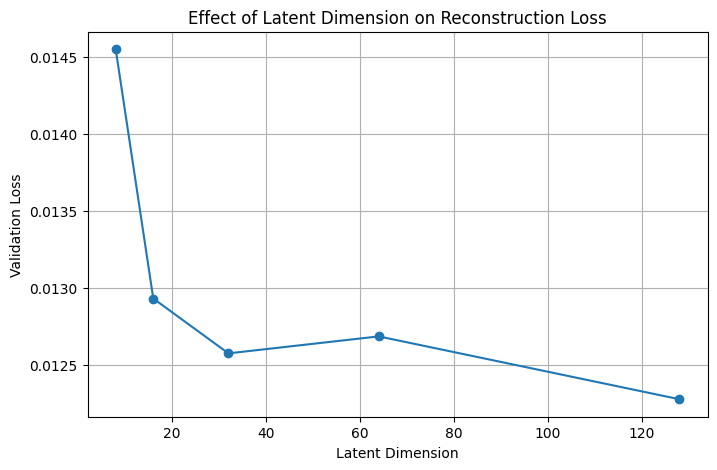

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(results.keys()),
    list(results.values()),
    marker="o"
)

plt.xlabel("Latent Dimension")
plt.ylabel("Validation Loss")
plt.title("Effect of Latent Dimension on Reconstruction Loss")

plt.grid(True)

plt.show()

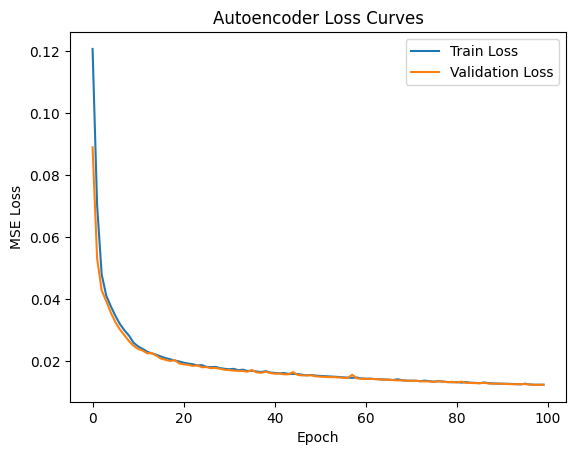

In [15]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Loss Curves")

plt.legend()
plt.show()

The latent dimension experiment demonstrates the trade-off between compression and reconstruction quality.

A latent dimension of 8 resulted in the highest validation loss, indicating that the bottleneck was too restrictive to preserve all important image features. Increasing the latent dimension consistently improved reconstruction quality, with the validation loss decreasing from approximately 0.0146 at 8 dimensions to 0.0123 at 128 dimensions.

The largest improvement occurred between 8 and 16 dimensions. Beyond 32 dimensions, the reduction in validation loss became much smaller, suggesting diminishing returns from increasing the size of the latent representation.

Overall, larger latent dimensions improve reconstruction quality, while smaller latent dimensions achieve stronger compression.